In [28]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [29]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [30]:
X

array([[-0.01229447, -1.63483138],
       [-1.7830314 ,  0.98910811],
       [ 1.59622201, -3.06394094],
       ...,
       [-6.94663309, -3.60036374],
       [-2.03069675, -0.29411678],
       [-7.85724916, -4.96264236]], shape=(1000, 2))

In [31]:
y

array([2, 0, 2, 2, 0, 0, 0, 2, 2, 1, 1, 2, 1, 0, 0, 2, 0, 0, 2, 2, 2, 0,
       1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 2, 2, 2, 2, 0, 2, 2, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 2, 0, 2, 1, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 1, 1, 2, 0,
       2, 2, 0, 1, 0, 1, 0, 2, 2, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 1, 1,
       2, 0, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 1, 0, 1, 1, 1, 0, 0, 1, 2, 2,
       2, 2, 0, 2, 2, 0, 1, 0, 2, 1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 0, 1, 2,
       1, 1, 0, 2, 1, 1, 2, 2, 2, 0, 1, 2, 1, 1, 0, 2, 1, 2, 0, 0, 0, 2,
       0, 0, 0, 1, 2, 0, 2, 1, 2, 2, 2, 1, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0,
       0, 0, 1, 2, 1, 1, 0, 2, 0, 2, 2, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0,
       2, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 0,
       2, 1, 2, 2, 0, 2, 0, 1, 1, 2, 0, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       2, 1, 1, 2, 2, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 0, 1, 1, 1, 1, 1, 2,
       0, 2, 2, 0, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 1, 1, 2, 2,
       2, 2, 0, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 0, 2,

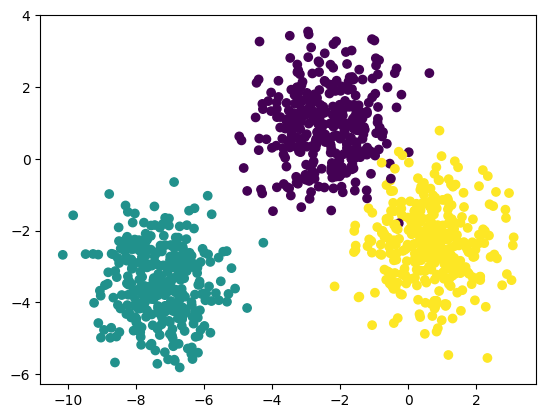

In [32]:
plt.scatter(X[:,0],X[:,1],c=y)

In [33]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [36]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
from sklearn.cluster import KMeans

In [38]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [39]:
wcss

[1340.0000000000002,
 591.0670593782613,
 210.365011539713,
 172.81933134052466,
 138.56567404239945,
 107.71858491462329,
 96.293394097932,
 86.77947138354094,
 80.72051963548265,
 71.8272404879013]

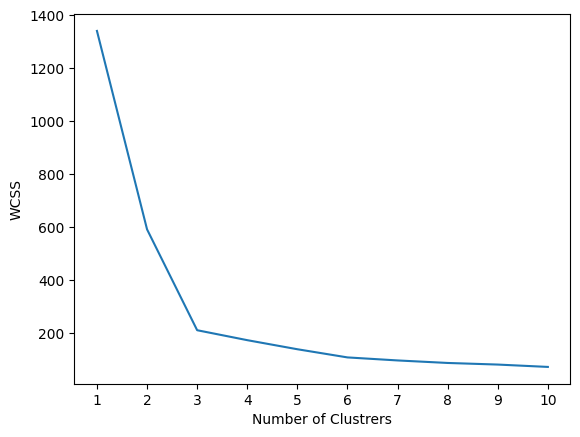

In [40]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [41]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [42]:
kmeans.fit_predict(X_train_scaled)

array([0, 0, 1, 1, 2, 0, 0, 1, 2, 2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 2, 1, 0,
       1, 1, 1, 2, 2, 0, 1, 1, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1,
       0, 0, 2, 2, 2, 1, 0, 1, 0, 0, 2, 1, 0, 1, 2, 0, 2, 1, 1, 2, 1, 0,
       1, 2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 2, 2, 0, 1, 2, 1, 2,
       2, 2, 2, 2, 2, 0, 1, 1, 2, 1, 1, 1, 2, 2, 1, 0, 0, 1, 0, 0, 1, 1,
       2, 1, 1, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 2, 2, 2,
       2, 0, 2, 1, 2, 2, 0, 0, 0, 0, 1, 0, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0,
       0, 0, 1, 2, 1, 0, 0, 2, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 1, 0, 0, 0, 1, 2, 0, 0, 1,
       2, 1, 1, 0, 1, 2, 1, 1, 2, 2, 1, 0, 2, 1, 0, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 1, 0, 1, 1, 0, 2, 1, 0, 2, 1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 0,
       0, 0, 2, 2, 1, 1, 2, 0, 2, 2, 2, 1, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2,
       1, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 0, 0, 1, 0,
       2, 2, 2, 1, 0, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2,

In [43]:
y_pred=kmeans.predict(X_test_scaled)

In [44]:
y_pred

array([1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2,
       0, 0, 1, 1, 0, 1, 2, 2, 1, 2, 0, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 0,
       0, 1, 0, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2,
       2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1, 1, 0, 0, 2, 0, 2, 2, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0, 2, 0, 1, 2, 2,
       2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       2, 2, 0, 2, 2, 1, 2, 0, 1, 2, 1, 0, 1, 1, 0, 1, 1, 0, 0, 2, 1, 0,
       1, 2, 1, 0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 1,
       2, 1, 1, 0, 2, 1, 0, 0, 2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 1, 2, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 2, 1, 1, 2,
       1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 2, 2, 1, 1, 0, 1, 2, 1, 0, 1, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 1, 0, 2, 2, 0, 0, 2, 2, 0,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 0, 0,

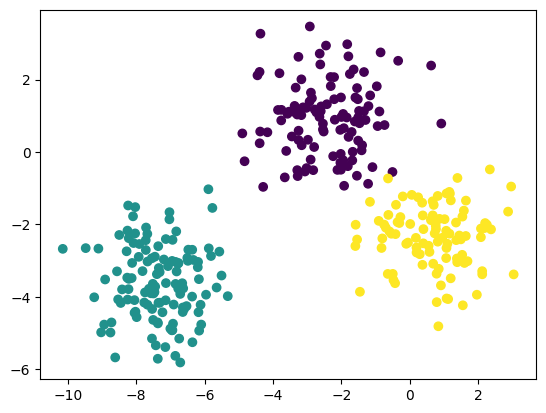

In [45]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [46]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [47]:
from kneed import KneeLocator

In [48]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [49]:
kl.elbow

np.int64(3)

In [50]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [51]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [52]:
silhouette_coefficients

[0.5574022345423031,
 0.6384380693406573,
 0.5273396786778787,
 0.48149427728503197,
 0.3976680935248856,
 0.3817366334427647,
 0.3457692631112068,
 0.33357447654555566,
 0.3353071381823688]

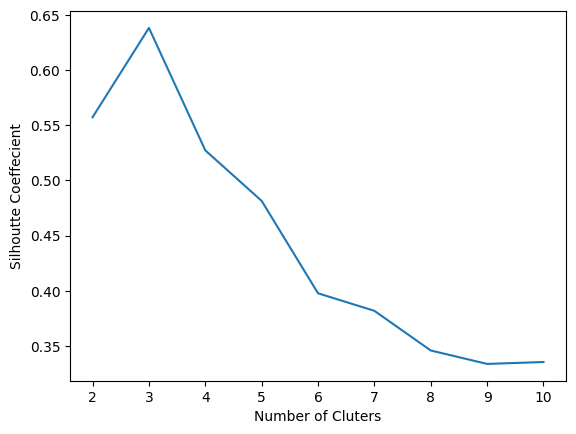

In [53]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()